✅ Libraries imported successfully!
✅ Dataset loaded successfully!
Dataset shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

✅ Missing values handled!

Features shape: (768, 8)
Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

0 = No Diabetes: 500
1 = Has Diabetes: 268

✅ Data split done!
Training

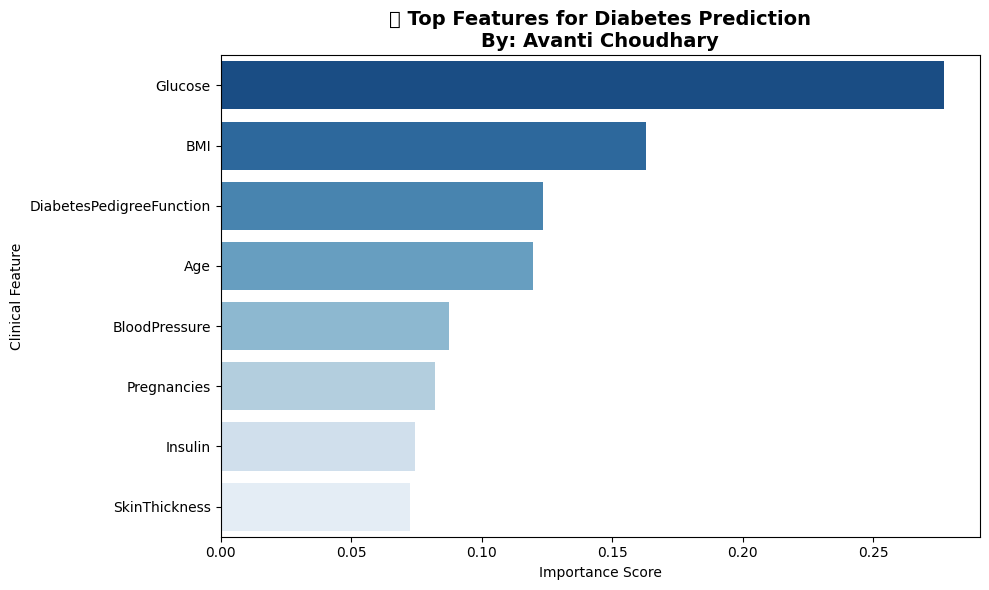


✅ Chart saved!

🎉 PROJECT COMPLETE!
Model: Random Forest Classifier
Accuracy: 75.97%
AUC-ROC: 0.8200
Ready for GitHub upload! ✅


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                            classification_report,
                            roc_auc_score,
                            confusion_matrix)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
# STEP 2 - Load dataset directly from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ['Pregnancies','Glucose','BloodPressure',
           'SkinThickness','Insulin','BMI',
           'DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv(url, names=columns)
print("✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# STEP 3 - Handle missing values
# Zeros in these columns are actually missing values
for col in ['Glucose','BloodPressure',
            'SkinThickness','Insulin','BMI']:
    df[col] = df[col].replace(0, df[col].median())

print("\n✅ Missing values handled!")

# STEP 4 - Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\n0 = No Diabetes: {y.value_counts()[0]}")
print(f"1 = Has Diabetes: {y.value_counts()[1]}")

# STEP 5 - Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f"\n✅ Data split done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# STEP 6 - Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n✅ Features scaled successfully!")

# STEP 7 - Train the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

model.fit(X_train, y_train)
print("\n✅ Model trained successfully!")

# STEP 8 - Make predictions
predictions = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:,1]

# STEP 9 - Show results
accuracy = accuracy_score(y_test, predictions)
auc_roc = roc_auc_score(y_test, pred_proba)

print("\n" + "="*50)
print("🎯 DIABETES PREDICTION MODEL RESULTS")
print("="*50)
print(f"✅ Accuracy:  {accuracy*100:.2f}%")
print(f"✅ AUC-ROC:   {auc_roc:.4f}")
print("\n📊 Detailed Report:")
print(classification_report(y_test, predictions,
      target_names=['No Diabetes','Has Diabetes']))

# STEP 10 - Feature importance chart
feature_importance = pd.DataFrame({
    'Feature': columns[:-1],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance,
            x='Importance',
            y='Feature',
            palette='Blues_r')
plt.title('🩺 Top Features for Diabetes Prediction\nBy: Avanti Choudhary',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Feature')
plt.tight_layout()
plt.savefig('diabetes_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved!")

print("\n" + "="*50)
print("🎉 PROJECT COMPLETE!")
print("="*50)
print(f"Model: Random Forest Classifier")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"AUC-ROC: {auc_roc:.4f}")
print("Ready for GitHub upload! ✅")

